In [365]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## Zadanie 1
    
Wczytaj dane z pliku **PersonalData.csv**.
    
Oblicz odległość euklidesową \(d(A, B)\) między dwoma wybranymi rekordami \(A\) i \(B\).
    
Zmodyfikuj skalę dla atrybutu **zarobki** (przeskaluj jednostki z tysięcy na złote) i ponownie oblicz odległość euklidesową. Jak zmiana skali wpływa na wynik?
    
Aby wyeliminować wpływ skali, podziel wartość każdego atrybutu przez jego odchylenie standardowe. Oblicz ponownie odległość euklidesową dla przeskalowanych danych.
    
Dla punktów \(A\) i \(B\) oblicz także odległość Minkowskiego oraz odległość miejską (Manhattan).

In [366]:
df = pd.read_csv('PersonalData.csv')

num_cols = [
   'Wzrost (cm)',
   'Waga (kg)',
   'Staz (lata)',
   'Zarobki (tys.)',
   'Ocena (pkt.)',
   'Piętro',
   'Dzieci',
   'Odleglosc (km)'
]

A = df.loc[0, num_cols].values.astype(float)
B = df.loc[1, num_cols].values.astype(float)

euclid = np.sqrt(np.sum((A - B) ** 2))
print(f'Odległość euklidesowa: {euclid}')


A2 = A.copy()
B2 = B.copy()

salary_idx = num_cols.index('Zarobki (tys.)')
A2[salary_idx] *= 1000
B2[salary_idx] *= 1000

euclid_scaled = np.sqrt(np.sum((A2 - B2) ** 2))
print(f'Odległość euklidesowa (przeskalowane): {euclid_scaled}')


std = df[num_cols].std().values

A_std = A / std
B_std = B / std

euclid_std = np.sqrt(np.sum((A_std - B_std) ** 2))
print(f'Odległość euklidesowa (dzielone przez odchylenie): {euclid_std}')


p = 3
minkowski = np.sum(np.abs(A - B)**p)**(1/p)
print(f'Odległość Minkowskiego na P= {p}: {minkowski}')

manhattan = np.sum(np.abs(A - B))
print(f'Odległość Manhattan: {manhattan}')

Odległość euklidesowa: 30.604574821421714
Odległość euklidesowa (przeskalowane): 800.5847862656397
Odległość euklidesowa (dzielone przez odchylenie): 4.0
Odległość Minkowskiego na P= 3: 24.524624416199366
Odległość Manhattan: 68.8


## Zadanie 2

Napisz program pozwalający obliczać podobieństwo między sekwencjami DNA traktowanymi jako ciągi znaków.

Zaimplementować na podstawie metryki
$$
D(x, y) = |x| + |y| - 2|LCS(x,y)|
$$

gdzie LCS oznacza najdłuszą wspólna podsekwencję (ang.
longest common subsequence)
  
  (LCS(x,y) = bcde). D(x, y) = 3

In [367]:
def get_LCS(x, y, lx, ly):
  if lx == 0 or ly == 0:
      return 0;
  elif x[lx-1] == y[ly-1]:
      return 1 + get_LCS(x, y, lx-1, ly-1);
  else:
      return max(get_LCS(x, y, lx, ly-1), get_LCS(x, y, lx-1, ly));

def get_D_x_y(x, y):
  lx = len(x)
  ly = len(y)

  if ((not any(c in y for c in x))):
    return lx + ly

  LCS = get_LCS(x, y, lx, ly)

  return lx + ly - 2 * LCS

x = "abcde"
y = "bcdxye"
print(get_D_x_y(x, y)) # Oczekiwany wynik 3

X = "AGGTAB"
Y = "GXTXAYB"
print(get_D_x_y(X, Y)) # Oczekiwany wynik 5

3
5


## Zadanie 3

Masz opisy trzech filmów
- `film1 = "kosmiczna stacja astronauta planeta obca"`
- `film2 = "astronauta rakieta księżyc misja kosmiczna"`
- `film3 = "wampir zamek noc krew mroczny"`

a. Stwórz reprezentację wektorową dla każdego filmu używając CountVectorizer

b. Oblicz podobieństwo cosinusowe między wszystkimi parami filmów

c. Które dwa filmy są najbardziej podobne? Które najmniej?

d . Dodaj czwarty film i sprawdź do którego jest najbardziej podobny:
    `film4 = "rakieta mars astronauta czerwona planeta"`

In [368]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

films = [
    "kosmiczna stacja astronauta planeta obca",
    "astronauta rakieta księżyc misja kosmiczna",
    "wampir zamek noc krew mroczny"
]

# a
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(films)
print(f'Po wektoryzacji: \n{X.toarray()}')
# b
print(f'Wektor odległości cosinusowych: \n{cosine_similarity(X)}')

Po wektoryzacji: 
[[1 1 0 0 0 0 0 1 1 0 1 0 0]
 [1 1 0 1 1 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 1 1 0 0 0 0 1 1]]
Wektor odległości cosinusowych: 
[[1.  0.4 0. ]
 [0.4 1.  0. ]
 [0.  0.  1. ]]


- Powyższa tabela podobieństw składa się z 3 wierszy, gdzie każdy kolejny element wiersza wskazuje podobieństwo do kolejno pierwszego, drugiego oraz trzeciego elementu.

- Interpretacja wskazuje, że opisy filmów 1 i 2 są najbardziej podobne, natomiast opis 3 nie jest wcale podobny do pozostałych. Faktycznie widać, że nie ma on żadnych "wspólnych" słów z pozostałymi.



In [369]:
film4 = "rakieta mars astronauta czerwona planeta"
# films4 = films + [film4]
films.append(film4)

print(films)
vectorizer2 = CountVectorizer()
X_all = vectorizer2.fit_transform(films)

print(f'Rozszerzony wektor odległości cosinusowych: \n{cosine_similarity(X_all)}')

['kosmiczna stacja astronauta planeta obca', 'astronauta rakieta księżyc misja kosmiczna', 'wampir zamek noc krew mroczny', 'rakieta mars astronauta czerwona planeta']
Rozszerzony wektor odległości cosinusowych: 
[[1.  0.4 0.  0.4]
 [0.4 1.  0.  0.4]
 [0.  0.  1.  0. ]
 [0.4 0.4 0.  1. ]]


- Powyższa tabela podobieństw składa się z teraz 4 wierszy. Nowy wiersz jest najbardziej podobny do pierwszego oraz drugiego opisu


## Zadanie 4

A. Wczytaj dane z pliku **k_means_data.csv.**

B. Zastosuj **algorytm hierarchiczny aglomeracyjny** i wyszukaj w zbiorze danych klastry.

C. Zastosuj **algorytm k-średnich** i wyszukaj w zbiorze danych klastry.

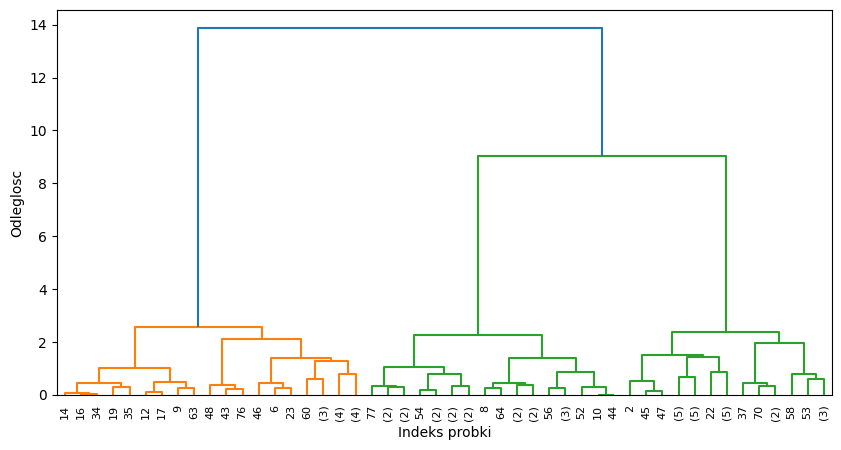

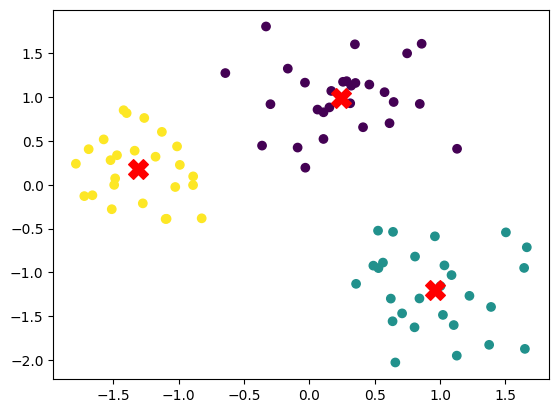

In [370]:
from sklearn . cluster import KMeans
from sklearn . preprocessing import StandardScaler
import matplotlib . pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# A
df2 = pd.read_csv('k_means_data.csv')
X = df2.select_dtypes(include="number").values

# B
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method='ward')
labels_h = fcluster(Z, t=3, criterion='maxclust')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5)
plt.xlabel('Indeks probki')
plt.ylabel('Odleglosc')
plt.show()

# C
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

labels_k = kmeans.labels_
centers = kmeans.cluster_centers_

plt.scatter(X_scaled[: ,0], X_scaled[: ,1], c=labels_k, cmap='viridis')
plt.scatter(centers[: ,0],centers[: ,1], c='red', marker='X', s=200)


## Zadanie 5

Zaimplementuj samodzielnie **algorytm k-średnich** dla danych z pliku **k_means_data.csv**.

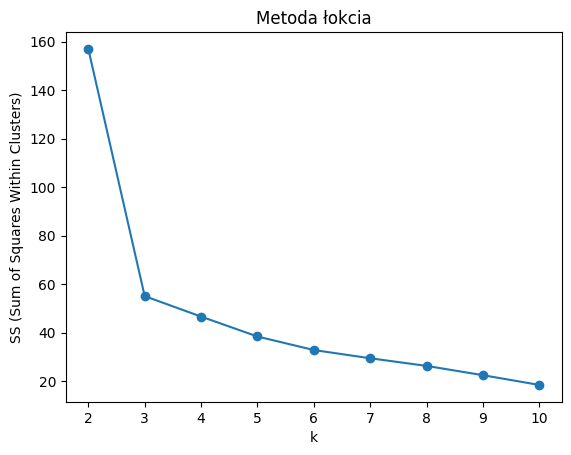

K = 3 | SS = 55.0695168333159
len(labels) = 80 | df.shape[0] = 80
       # X1        X2  cluster
0  2.131415  1.138857        1
1  2.161723  0.656595        1
2  1.062696  5.176351        2
3  1.807096  0.449191        1
4  2.269087  1.321608        1


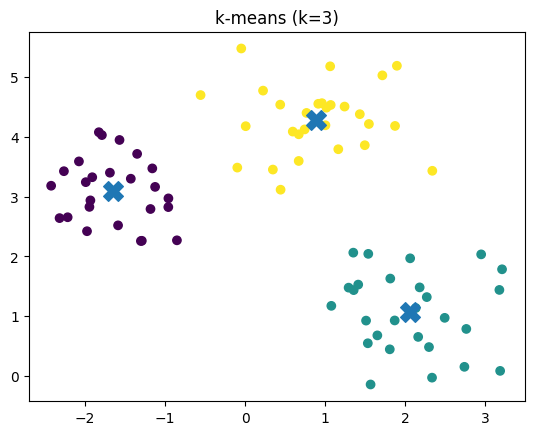

In [371]:
def kmeans(X, k, max_iter=100, seed=0):
  np.random.seed(seed)

  labels = np.random.randint(0, k, size=len(X))

  centroids = np.zeros((k, X.shape[1]))
  for j in range(k):
    points = X[labels == j]
    if len(points) > 0:
      centroids[j] = points.mean(axis=0)
    else:
      centroids[j] = X[np.random.randint(len(X))]

  for it in range(max_iter):
    old_labels = labels.copy()

    distances = np.sqrt(((X[:, None] - centroids) ** 2).sum(axis=2))
    labels = np.argmin(distances, axis=1)

    for j in range(k):
      points = X[labels == j]
      if len(points) > 0:
        centroids[j] = points.mean(axis=0)
      else:
        centroids[j] = X[np.random.randint(len(X))]

    if np.array_equal(labels, old_labels):
        break

  SS = 0
  for j in range(k):
    for x in X[labels == j]:
        SS += np.sum((x - centroids[j]) ** 2)

  return labels, centroids, SS

def kmeans_best(X, k, n_init=10, max_iter=100):
  best_labels = None
  best_centroids = None
  best_SS = None

  for seed in range(n_init):
    labels, centroids, SS = kmeans(X, k, max_iter=max_iter, seed=seed)
    if best_SS is None or SS < best_SS:
      best_SS = SS
      best_labels = labels
      best_centroids = centroids

  return best_labels, best_centroids, best_SS


Ks = range(2, 11)
SSes = []

for k in Ks:
    _, _, SS = kmeans_best(X, k, n_init=10, max_iter=100)
    SSes.append(SS)

plt.plot(list(Ks), SSes, marker="o")
plt.xlabel("k")
plt.ylabel("SS (Sum of Squares Within Clusters)")
plt.title("Metoda łokcia")
plt.show()

K_FINAL = 3
labels, centroids, SS = kmeans_best(X, K_FINAL, n_init=20, max_iter=100)

print("K =", K_FINAL, "| SS =", SS)
print("len(labels) =", len(labels), "| df.shape[0] =", df2.shape[0])

df2["cluster"] = labels
print(df2.head())

if X.shape[1] >= 2:
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200)
    plt.title(f"k-means (k={K_FINAL})")
    plt.show()


## Zadanie 6

1. Załaduj zbiór danych **iris**.
Opis zbioru: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html
2. Narysuj wykres rozrzutu dla współrzędnych **sepal_length** i **sepal_width**. Oznacz różnymi
kolorami i marklami różne klasy kwiatów.
3. Znajdź wartości **minimalne, maksymalne** oraz **średnie odchylenie kwadratowe** dla atrybutów zbioru.
4. Policz **współczynniki korelacji** między atrybutami.
5. Zastosuj **algorytm k-średnich** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.
6. Zastosuj **algorytm hierarchiczny aglomeracyjny** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.

In [372]:
# 1. Wczytanie zbioru danych Iris
iris = datasets.load_iris()

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df_i = pd.DataFrame(X, columns=feature_names)
df_i["class"] = y

print(df_i.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  


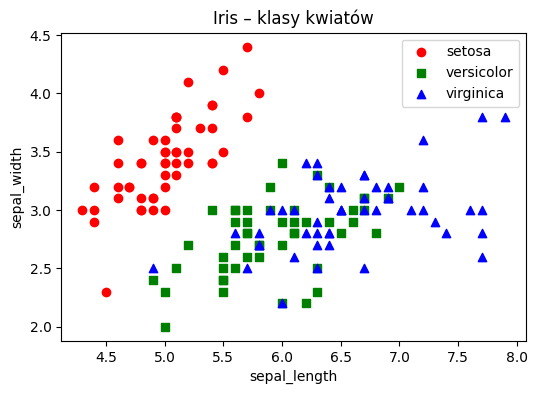

In [373]:
# 2
plt.figure(figsize=(6,4))

markers = ["o", "s", "^"]
colors = ["red", "green", "blue"]

for i, name in enumerate(target_names):
  subset = df_i[df_i["class"] == i]
  plt.scatter(
    subset["sepal length (cm)"],
    subset["sepal width (cm)"],
    marker=markers[i],
    color=colors[i],
    label=name
  )

plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("Iris – klasy kwiatów")
plt.legend()
plt.show()

In [374]:
# 3
stats = pd.DataFrame({
    "min": df_i[feature_names].min(),
    "max": df_i[feature_names].max(),
    "std": df_i[feature_names].std()
})

print(stats)

                   min  max       std
sepal length (cm)  4.3  7.9  0.828066
sepal width (cm)   2.0  4.4  0.435866
petal length (cm)  1.0  6.9  1.765298
petal width (cm)   0.1  2.5  0.762238


In [375]:
# 4
corr = df_i[feature_names].corr()
print(corr)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


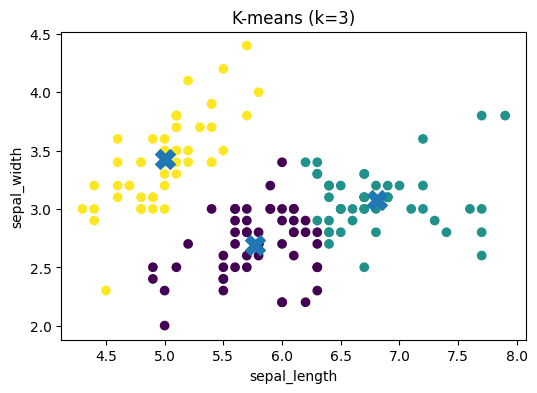

In [376]:
# 5
X2 = df_i[["sepal length (cm)", "sepal width (cm)"]].values

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_km = kmeans.fit_predict(X2)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(6,4))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_km)
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200)
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("K-means (k=3)")
plt.show()

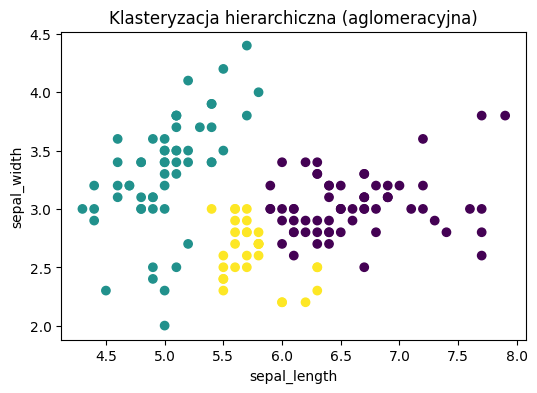

In [377]:
# 6
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X2)

plt.figure(figsize=(6,4))
plt.scatter(X2[:, 0], X2[:, 1], c=labels_agg)
plt.xlabel("sepal_length")
plt.ylabel("sepal_width")
plt.title("Klasteryzacja hierarchiczna (aglomeracyjna)")
plt.show()

## Zadanie 7
Dla danych z pliku penguins.csv wykonaj polecenia

Wyświetl podstawowe informacje o zbiorze.
1. Sprawdź czy w zbiorze nie brakuje danych. Jeżeli są – usuń je ().
2. Ogranicz się do atrybutów **bill_length_mm** i **flipper_length_mm**.
3. Narysuj dendogram, zinterpretuj go i wyznacz ilość klastrów.
4. Zastosuj algorytm hierarchiczny aglomeracyjny do zbioru i wyznacz klastry.
5. Stwórz wykres rozrzutu z zaznaczonymi klastrami.

W **punktach 3-5** przetestuj różne sposoby obliczenia odległości między klastrami (linkage-complete, average, single, ward).

Dane z https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv

In [378]:
# 0
df_p = pd.read_csv('penguins.csv')

print("Wiersze początkowe:")
display(df_p.head())

print("\nPodstawowe infofrmacje:")
print(df_p.info())

Wiersze początkowe:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE



Podstawowe infofrmacje:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [379]:
# 1
print("Braki danych:")
print(df_p.isna().sum())

Braki danych:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [380]:
# 2
cols = ["bill_length_mm", "flipper_length_mm"]
df2_p = df_p[cols].copy()
df2_p = df2_p.dropna()

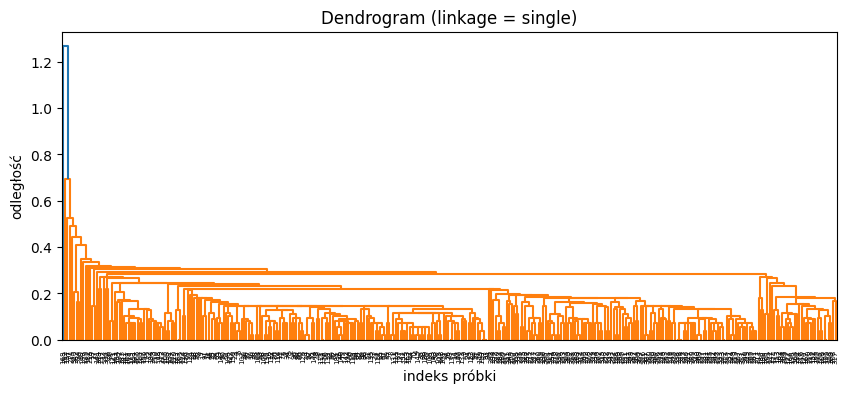

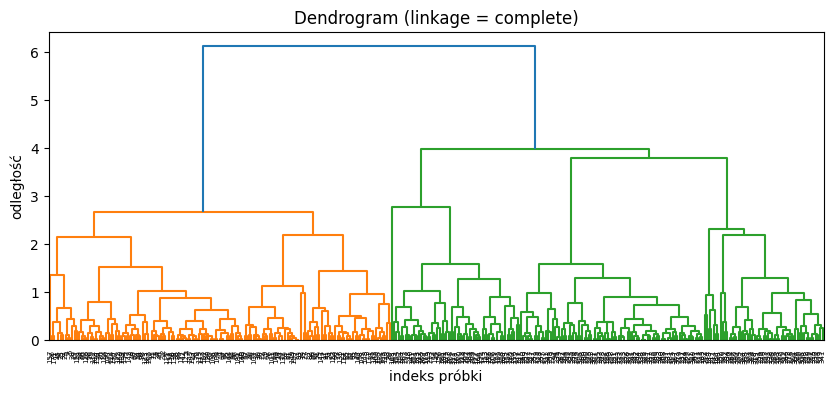

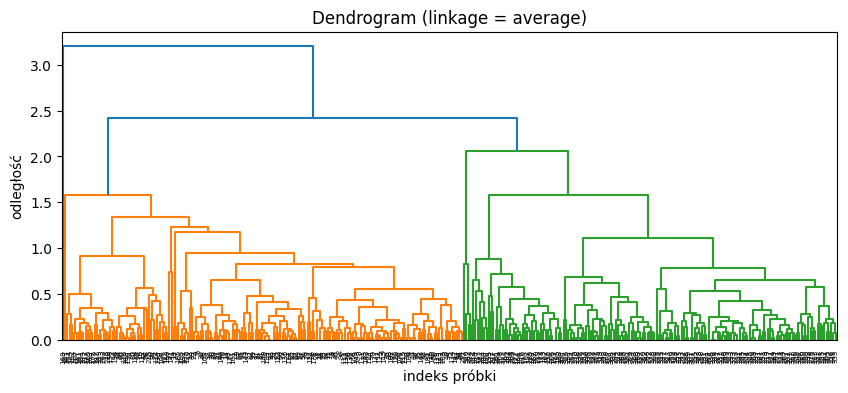

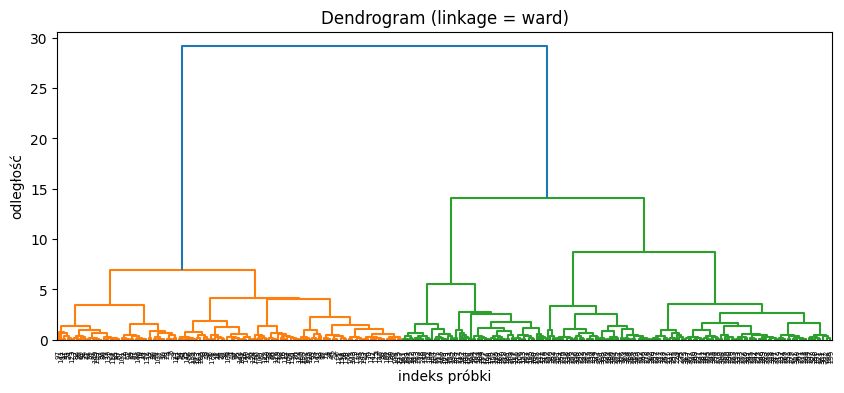

In [381]:
# 3
X = df2_p.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

linkage_methods = ["single", "complete", "average", "ward"]

for m in linkage_methods:
    Z = linkage(X_scaled, method=m)
    plt.figure(figsize=(10, 4))
    dendrogram(Z)
    plt.title(f"Dendrogram (linkage = {m})")
    plt.xlabel("indeks próbki")
    plt.ylabel("odległość")
    plt.show()

Według mnie najlepszy do interpretacji jest dendrogram wykonany z linkage=ward, dlatego że widzimy bardzo długą linię niepodobieństwa łączącą poziomy około 6 oraz 30. Stawiając poziomą linię tuż poniżej tego skoku widać trzy wyraźne grupy, stąd wybór k=3 klastrów.

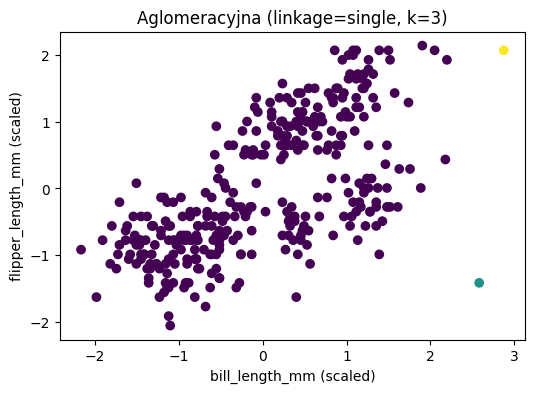

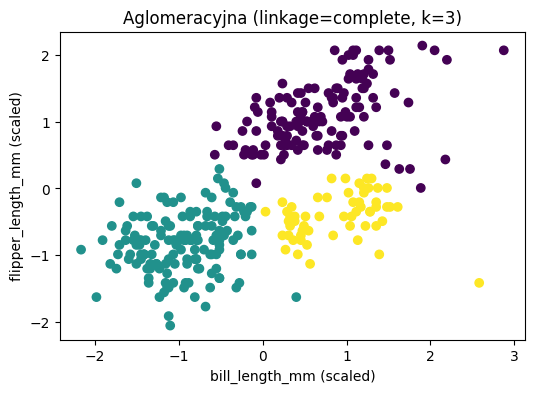

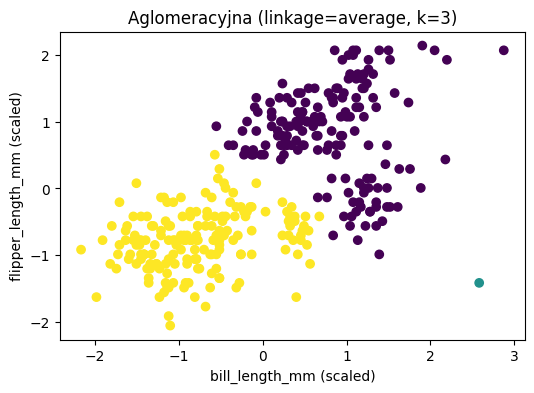

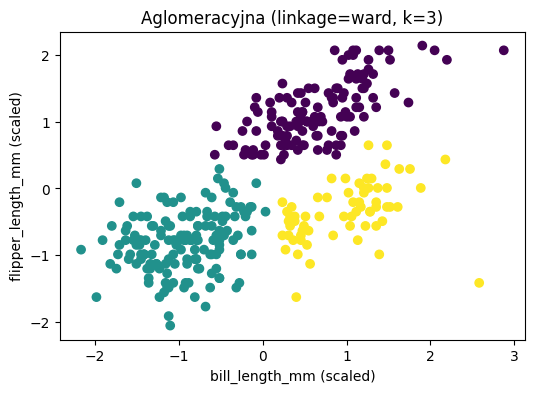

In [382]:
# 4 i 5
for m in linkage_methods:
  if m == "ward":
    agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
  else:
    agg = AgglomerativeClustering(n_clusters=3, linkage=m, metric="euclidean")

  labels_agg = agg.fit_predict(X_scaled)

  plt.figure(figsize=(6,4))
  plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg)
  plt.xlabel("bill_length_mm (scaled)")
  plt.ylabel("flipper_length_mm (scaled)")
  plt.title(f"Aglomeracyjna (linkage={m}, k=3)")
  plt.show()

Jak widać powyżej, liczba klastrów k = 3 daje czytelne wyniki dla metod linkage = ward oraz complete.
W przypadku pozostałych metod otrzymane wykresy są mniej czytelne dla tej samej liczby klastrów. Takich wyników można spodziewać się patrząc na dendrogramy, które w przypadku linkage = single pokazują wyraźnie jeden duży klaster (k=1), co do linkage=average to z powodu odstająćych punktów trudno jest jednoznacnzie wybrać liczbę klastrów.


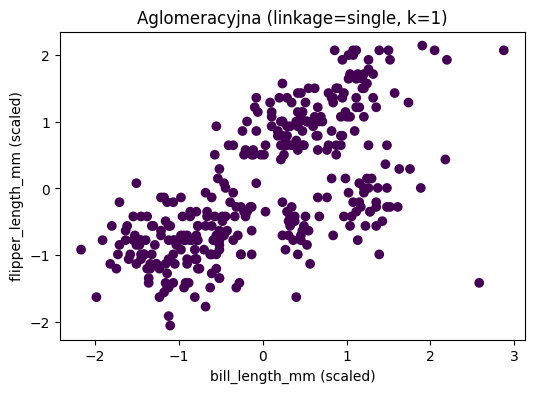

In [383]:
agg_sing = AgglomerativeClustering(n_clusters=1, linkage="single", metric="euclidean")

labels_agg_sing = agg_sing.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg_sing)
plt.xlabel("bill_length_mm (scaled)")
plt.ylabel("flipper_length_mm (scaled)")
plt.title(f"Aglomeracyjna (linkage=single, k=1)")
plt.show()

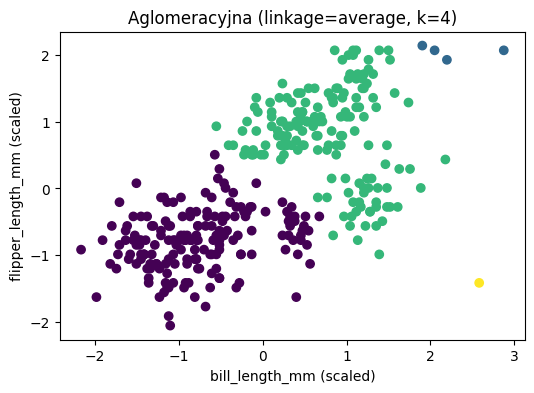

In [384]:
agg_avg = AgglomerativeClustering(n_clusters=4, linkage="average", metric="euclidean")

labels_agg_average = agg_avg.fit_predict(X_scaled)

plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_agg_average)
plt.xlabel("bill_length_mm (scaled)")
plt.ylabel("flipper_length_mm (scaled)")
plt.title(f"Aglomeracyjna (linkage=average, k=4)")
plt.show()